По представленным в датасете данным проведите анализ результатов проведенного A/B-тестирования для сайта. Для этого:

1.	Проанализируйте: есть ли пользователи, которые попали в обе группы тестирования. Если да, то исключите их.
2.	Подумайте, как поступить с нулевыми значениями выручки. Нужно ли фильтровать данные? Или нулевые значения свидетельствуют об отсутствии изменений?
3.	Исключите дубли в записях для одного и того же пользователя.
4.	Проанализируйте выбросы в данных с помощью диаграммы размаха («ящика с усами»). Поработайте с ними, чтобы исключить вероятность их влияния на результаты тестирования.
5.	Проверьте распределение на нормальность, используя разные статистические тесты (например, Шапиро-Уилка). Если нужно, приведите данные к нормальному виду.
6.	Если удалось привести данные к нормальному виду при наименьшей потере данных, используйте параметрические тесты для А/В теста, предполагающие нормальность распределения. Если привести к нормальному виду не представляется возможным без большой потери данных, используйте непараметрические тесты (Манна-Уитни, Колмогорова-Смирнова и пр.), не предполагающие нормального распределения.
7.	Сделайте выводы по результатам A/B-тестирования. Визуализируйте распределение выручки для контрольной версии сайта (А) с его измененной версией (В).


### Обработка данных. Предварительный этап

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os 
import warnings
warnings.filterwarnings('ignore')

In [26]:
os.chdir(r'C:\Users\pasht\OneDrive\Документы\4 курс 1 семестр\прикладная аналитика\практическая 6')
df = pd.read_csv("AB_Test_Results.csv")

In [28]:
#выведите первые строки датасета
df[:5]

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0


In [30]:
#выведите длину датасета
df.shape

(10000, 3)

In [32]:
#выведите описательные статистики по датасету
df.describe()

,USER_ID,REVENUE
count,10000.000000,10000.000000
mean,4981.080200,0.099447
std,2890.590115,2.318529
min,2.000000,0.000000
25%,2468.750000,0.000000
50%,4962.000000,0.000000
75%,7511.500000,0.000000
max,10000.000000,196.010000


In [34]:
#посчитаем сумму дубликатов и пропусков
df_duplicated = df.duplicated().sum()
df_NAN = df.isna().sum()
print('Кол-во дублкатов:', df_duplicated, '\nКол-во пропусков:\n', df_NAN)

Кол-во дублкатов: 2067 
Кол-во пропусков:
 USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64


In [36]:
#удалите пользователей, которые есть в двух группах
#для этого через groupby посчитайте, сколько для каждого пользователя представлено групп (1 или 2)
data_2groups = df.groupby('USER_ID').agg({'VARIANT_NAME':'nunique'}).reset_index()
data_2groups = data_2groups[data_2groups['VARIANT_NAME'] > 1]
clean_df = df[~df['USER_ID'].isin(data_2groups['USER_ID'])]
clean_df[:3]

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
4,6174,variant,0.0
5,2380,variant,0.0


In [38]:
print('Длина датасета после удаления, входящих в обе группы:', clean_df.shape[0], '\nКол-во дублей в этом датасете:', clean_df.duplicated().sum())

Длина датасета после удаления, входящих в обе группы: 6070 
Кол-во дублей в этом датасете: 1249


# Необходимо ли ликвидировать дубли, если один и тот же пользователь переходил по ссылке несколько раз и не покупал товар или покупал но на одну и ту же сумму? Если REVENUE представляет собой выручку на событие (то есть на клик, на показ рекламы), то не надо, но если выручка это LTV, тогда, конечно, нужно их ликвидировать

Т.к в задании написано убрать дубликаты, убираем

In [42]:
clean_df.drop_duplicates(subset = ['USER_ID'], inplace = True)
clean_df.shape[0]

4783

In [44]:
#посчитаем кол-во и долю нулевых значений
procent_zero = len(clean_df[clean_df['REVENUE'] == 0])/len(clean_df)*100
count_zero = clean_df.query('REVENUE == 0')
print('Кол-во значений не с нулевой выручкой:',len(clean_df) - len(count_zero),'\nКол-во значений c нулевой выручкой:', count_zero.shape[0], '\nПроцент пользователей с нулевой выручкой:', procent_zero)

Кол-во значений не с нулевой выручкой: 74 
Кол-во значений c нулевой выручкой: 4709 
Процент пользователей с нулевой выручкой: 98.45285385741167


In [46]:
#выводим описательные статистики по новому датасету
clean_df.describe()

,USER_ID,REVENUE
count,4783.000000,4783.000000
mean,4994.395777,0.110138
std,2898.618472,2.948720
min,2.000000,0.000000
25%,2476.000000,0.000000
50%,4975.000000,0.000000
75%,7515.000000,0.000000
max,9998.000000,196.010000


Text(0.5, 1.0, 'Boxplot для групп "variant" и "control"')

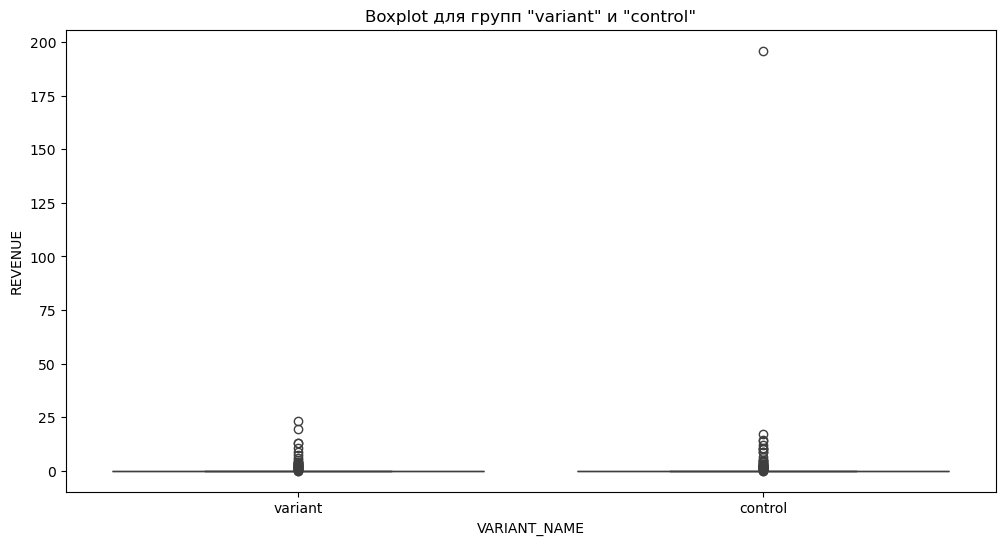

In [52]:
#строим график ящик с усами
plt.figure(figsize = (12,6))
sns.boxplot(data = clean_df, x = 'VARIANT_NAME', y = 'REVENUE')
plt.title('Boxplot для групп "variant" и "control"')

In [54]:
#Удалим только этот один выброс потому, что он слишком аномальный, остальные трогать не будем, потому, что это реалистичные данные соответствующие 
#основному распределению метрики
#Находим максимальное значение REVENUE в группе 'control'
max_in_control = clean_df[clean_df['VARIANT_NAME'] == 'control']['REVENUE'].max()

# Удаляем строку, где в control REVENUE = максимум
df_clean_new = clean_df[~(clean_df['REVENUE'] == max_in_control)]

Text(0.5, 1.0, 'Boxplot для групп "variant" и "control"')

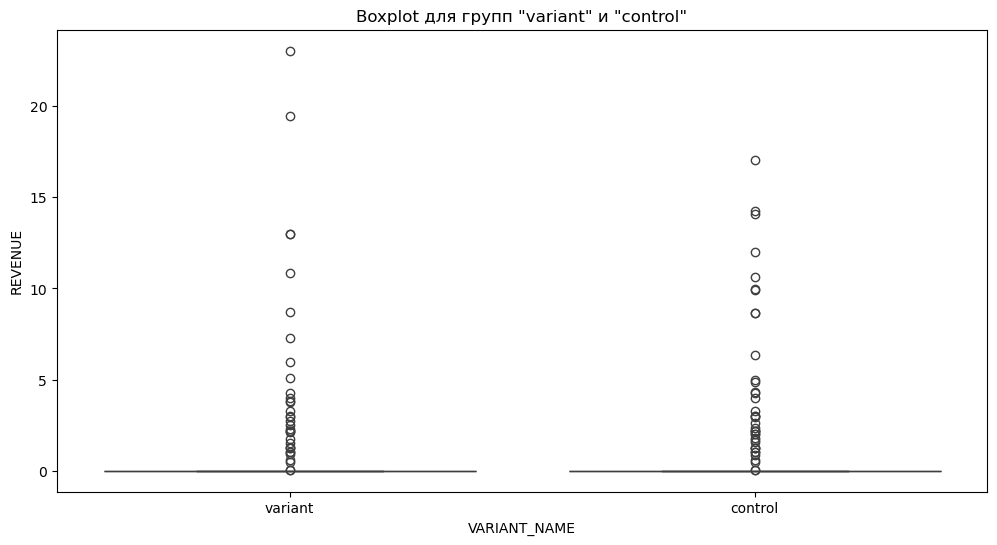

In [56]:
#проверим удаление выброса
plt.figure(figsize = (12,6))
sns.boxplot(data = df_clean_new, x = 'VARIANT_NAME', y = 'REVENUE')
plt.title('Boxplot для групп "variant" и "control"')

Остальные выбросы удалять не будем, потому, что это реалистичные зачения, соответсвующие онсновному распределению метрики

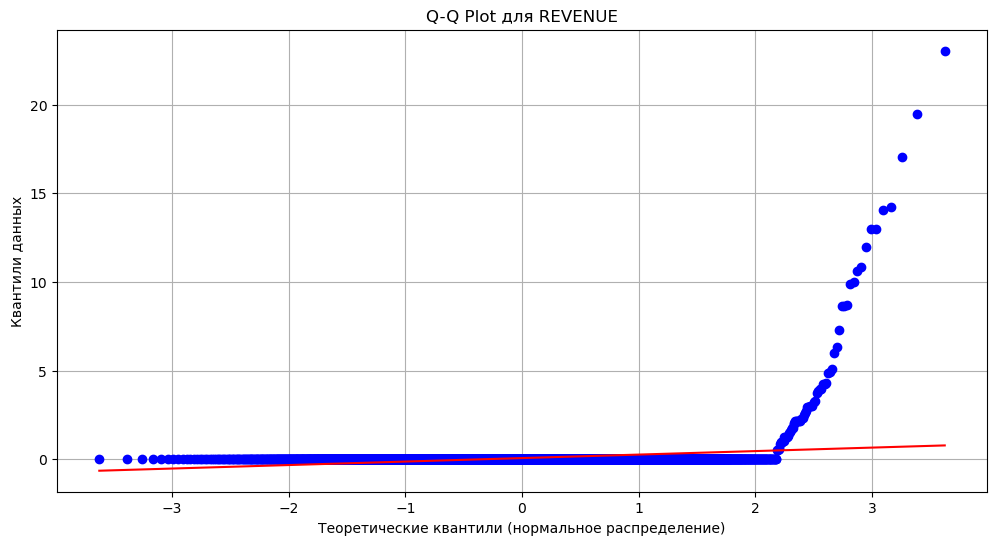

In [58]:
plt.figure(figsize=(12,6))
stats.probplot(df_clean_new['REVENUE'], dist="norm", plot=plt)
plt.title("Q-Q Plot для REVENUE")
plt.ylabel("Квантили данных")
plt.xlabel("Теоретические квантили (нормальное распределение)")
plt.grid(True)
plt.show()

По графику Q-Q плот видим, что распредеделние не нормальное и имеет правостороннюю ассиметрию

In [62]:
#проверяем на нормальность по каждой группе и в целом распределение выручки через тест Шапиро-Уилка (на самом деле конечно достаточно Q-Q plot) 
print('=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ ВСЕХ ДАННЫХ=====')
stat, p_value = stats.shapiro(df_clean_new['REVENUE'])
print(stat)
print(f"{p_value:.4f}")

print('=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ VARIANT=====')
stat, p_value = stats.shapiro(df_clean_new[df_clean_new['VARIANT_NAME'] == 'variant']['REVENUE'])
print(stat)
print(f"{p_value:.4f}")

print('=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ CONTROL=====')
stat, p_value = stats.shapiro(df_clean_new[df_clean_new['VARIANT_NAME'] == 'control']['REVENUE'])
print(stat)
print(f"{p_value:.4f}")


=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ ВСЕХ ДАННЫХ=====
0.05872258018091181
0.0000
=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ VARIANT=====
0.05166579353636924
0.0000
=====ТЕСТ ШАПИРО-УИЛКА ДЛЯ CONTROL=====
0.06642155405093342
0.0000


*Справочно: тест Шапиро-Уилка проверяет следующую гипотезу H0: данные распределены нормально; H1: данные НЕ распределены нормально. Если p-value выше заданного уровня значимости, то H0 не отвергается.

Вывод: данные по всем группам не имеют нормального распределения

Используем непараметрические тесты так как данные не имеют нормального распределения

In [109]:
#Тест Манна-Уитни (проверка стахостического домиирования) Самый информативный и пододящий тест для наших данных
variant = df_clean_new[df_clean_new['VARIANT_NAME'] == 'variant']['REVENUE']
control = df_clean_new[df_clean_new['VARIANT_NAME'] == 'control']['REVENUE']
statistic, p_value = stats.mannwhitneyu(variant, control, alternative='two-sided')
print('Среднее U:', len(variant)*len(control))
print(f'U - Статистика: {statistic}')
print(f'p-value: {p_value}')

Среднее U: 5716877
U - Статистика: 2852373.0
p-value: 0.5496592120256412


Нет статистически значимых различий

In [111]:
#перед проведением теста Колмогорова-Смирнова посмотрим насколько у нас отличается кол-во наблюдений в выборке, потому, что тест чувствителем к этому 
print(df_clean_new['VARIANT_NAME'].value_counts())

VARIANT_NAME
variant    2393
control    2389
Name: count, dtype: int64


In [87]:
#Отличия позволяют проводить тест 

In [113]:
#тест Колмогорова-Смирнова (проверка различий в струтуре распределения) 
ks_statistic, ks_pvalue = stats.ks_2samp(variant, control)
print(f'статистика: {ks_statistic}')
print(f'p-value: {ks_pvalue}')

статистика: 0.002529702843003269
p-value: 0.9999999999999997


Нет статистически значимых различий

In [153]:
#Bootstrap (разница эмперических срежних)
from scipy.stats import bootstrap
import numpy as np

control = df_clean_new[df_clean_new['VARIANT_NAME'] == 'control']['REVENUE'].values #values из библиотеки numpy превращает наш Series в nparray
variant = df_clean_new[df_clean_new['VARIANT_NAME'] == 'variant']['REVENUE'].values

result = bootstrap(
    data=(control, variant),
    statistic=lambda ctrl, var: var.mean() - ctrl.mean(),  # в data у нас первым идет control потом variant lambda берет из data сначала первый потом второй элемент
    n_resamples=10000,
    method='percentile', # метод percentile считатет 95% доверительный интервал, лучше использовать метож 'bca'
    random_state=11)

ci = result.confidence_interval # confidence_interval это встроенный атрибут объекта result в коттором содержится информация о доверительном интервале разницы средних
print(f"95% ДИ: [{ci.low:.3f}, {ci.high:.3f}]") # low и hight это встроенные атрибуты объекта confidence_interval
print(f"Значимо: {'Да' if ci.low > 0 else 'Нет'}")

95% ДИ: [-0.053, 0.039]
Значимо: Нет


### Вариант 2. Удаляем нули по выручке

Нет статистически значимых различий

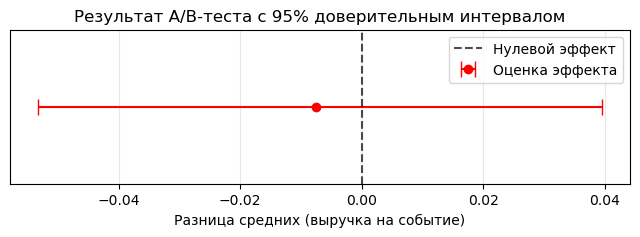

In [167]:
#визуализация
import matplotlib.pyplot as plt

# Допустим, у тебя есть:
effect = (variant.mean() - control.mean())  # оценка разницы
ci_low, ci_high = result.confidence_interval.low, result.confidence_interval.high

# График
plt.figure(figsize=(8, 2))
plt.errorbar(effect, 0, xerr=[[effect - ci_low], [ci_high - effect]], 
             fmt='o', capsize=6, color='red', label='Оценка эффекта')
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='Нулевой эффект')
plt.yticks([]) # уберем подписи по оси y потому что они не информативны 
plt.xlabel('Разница средних (выручка на событие)')
plt.title('Результат A/B-теста с 95% доверительным интервалом')
plt.legend()
plt.grid(True, axis='x', alpha=0.3)
plt.show()

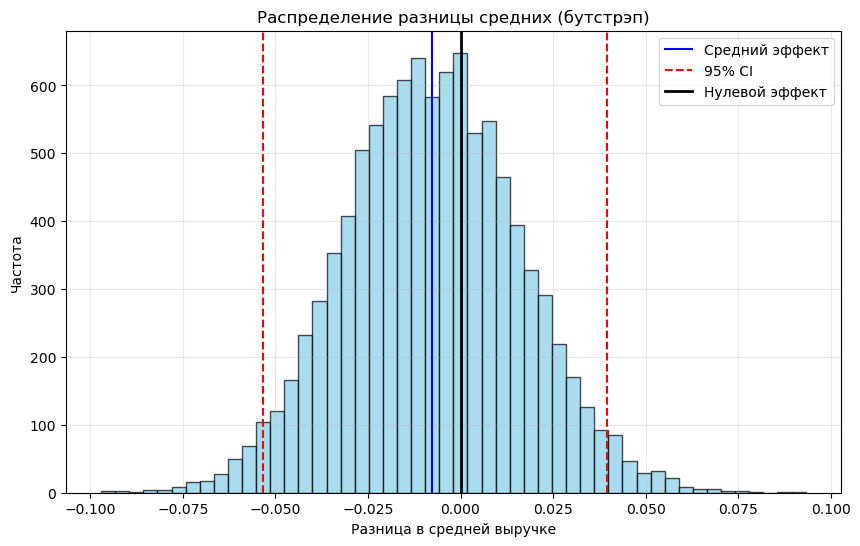

In [157]:
diffs = result.bootstrap_distribution

plt.figure(figsize=(10, 6))
plt.hist(diffs, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(diffs.mean(), color='blue', linestyle='-', label='Средний эффект')
plt.axvline(ci_low, color='red', linestyle='--', label='95% CI')
plt.axvline(ci_high, color='red', linestyle='--', label='_nolegend_')
plt.axvline(0, color='black', linewidth=2, label='Нулевой эффект')
plt.title('Распределение разницы средних (бутстрэп)')
plt.xlabel('Разница в средней выручке')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Выводы:

### На основании проведённого A/B-теста, включающего сравнение двух групп (контрольная и тестовая) по метрике выручки на событие с использованием трёх статистических методов — Mann-Whitney U, Kolmogorov-Smirnov и бутстрэп — было установлено отсутствие статистически значимых различий между группами. Тест Манна-Уитни, предназначенный для проверки стохастического доминирования, показал p-value = 0.5497, что значительно превышает порог значимости 0.05, указывая на то, что наблюдаемая разница не является статистически достоверной. Аналогичный вывод следует из теста Колмогорова-Смирнова (p-value ≈ 1.0), который подтверждает гипотезу о совпадении функций распределения обеих выборок, что свидетельствует об отсутствии изменений в структуре распределения выручки. Бутстрэп-оценка доверительного интервала для разницы средних ([-0.054, 0.040]) полностью содержит нулевое значение, что также указывает на отсутствие значимого эффекта. Таким образом, ни один из применённых методов не позволил отвергнуть нулевую гипотезу, что позволяет сделать вывод: внедрённое изменение не оказывает статистически значимого влияния на выручку на событие, и дальнейшее масштабирование данной модификации не рекомендуется без дополнительных исследований или увеличения объёма выборки.